In [13]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import json 
import numpy as np
import seaborn as sns

In [17]:
def billboard_lang_comp_hist(artist):

    billboard_file = open(f'processed_data/billboard_lang_percent/{artist}_billboard_lang_percent.json')
    billboard_data = json.load(billboard_file)

    billboard_df = pd.DataFrame(billboard_data['billboard_data'])

    langs_df = billboard_df['lang_percent'].apply(pd.Series)

    billboard_df = billboard_df.join(langs_df)

    condition = billboard_df['UNKNOWN'] == 1

    drop_indices = billboard_df[condition].index
    billboard_df.drop(drop_indices,inplace=True)

    fig, ax = plt.subplots(figsize=(10,6))

    if 'ENGLISH' in billboard_df:
        sns.histplot(data=billboard_df, x='ENGLISH', kde=True, label='English', color='#ef476f', bins=5, ax=ax)

    if 'KOREAN' in billboard_df:
        sns.histplot(data=billboard_df, x='KOREAN', kde=True, label='Korean', color='#118ab2', bins=5, ax=ax)

    if 'JAPANESE' in billboard_df:
        sns.histplot(data=billboard_df, x='JAPANESE', kde=True, label='Japanese', color='#ffd166', bins=5, ax=ax)

    plt.title(f'Frequency of Language Percentage of Billboard Global 200 Songs By {artist.upper()}', weight='bold')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'plots/billboard_lang_freq/{artist}.png')
    plt.show()



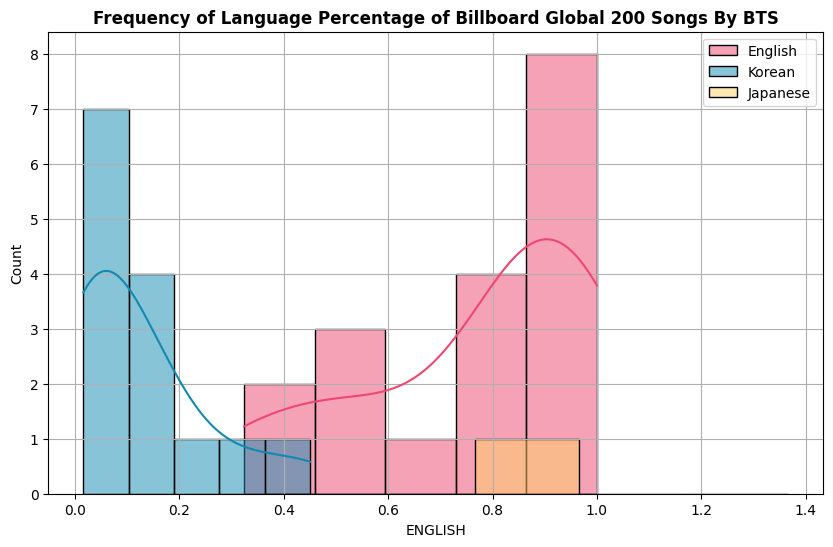

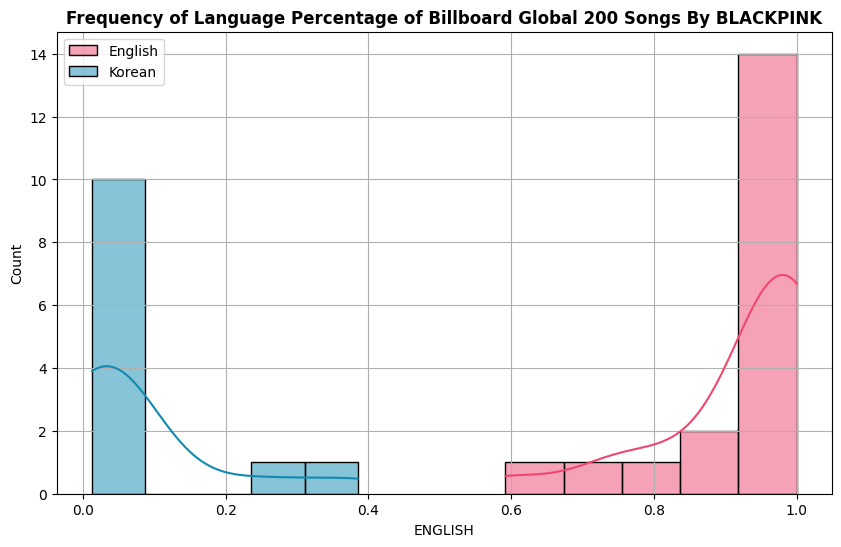

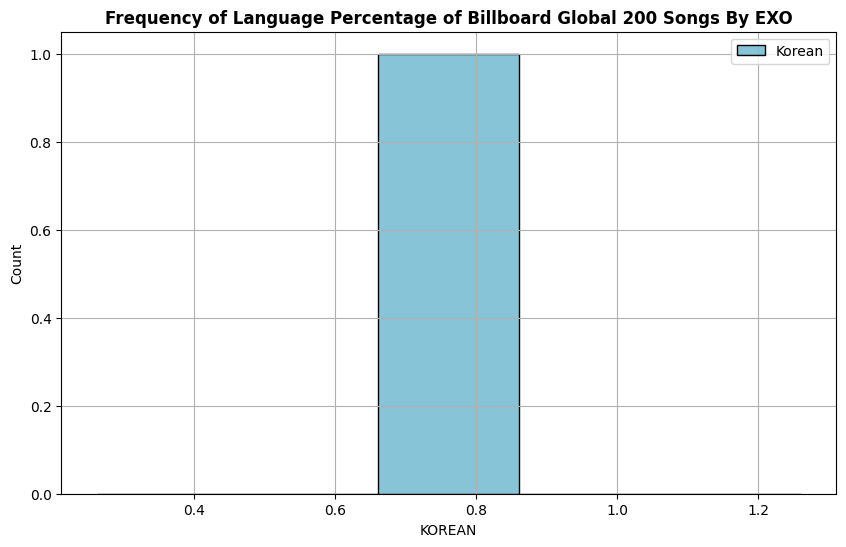

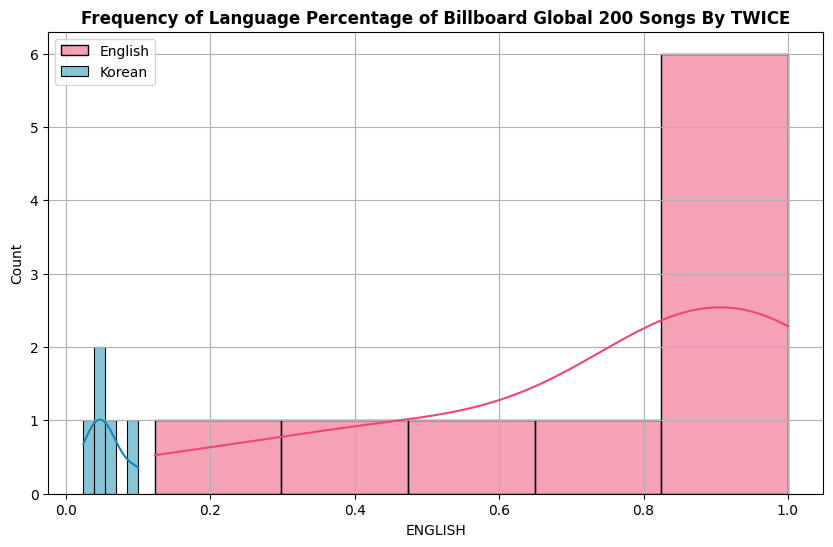

In [18]:
artists = ['bts','blackpink','exo','twice']
for artist in artists:
    billboard_lang_comp_hist(artist)